# Week 13 — Function 04

Focused, checksum-backed review of verified evidence through Week 11. No authoritative Week 12 or Week 13 returned output is treated as an observation.

## Table of contents

1. [Overview](#overview)
2. [Objectives](#objectives)
3. [Evidence provenance](#evidence-provenance)
4. [Environment and setup](#environment-setup)
5. [Data validation](#data-validation)
6. [Descriptive EDA](#descriptive-eda)
7. [Visual EDA](#visual-eda)
8. [GP model configuration](#gp-model-configuration)
9. [GP-UCB values](#gp-ucb-values)
10. [Reproducibility checks](#reproducibility-checks)
11. [Conclusions and next steps](#conclusions-next-steps)

<a id="overview"></a>
## 1. Overview

This notebook reviews one black-box function, presents bounded EDA, and surfaces the exact canonical Week 13 GP-UCB recommendation.

<a id="objectives"></a>
## 2. Objectives

Validate the cumulative evidence, describe the observed search history, inspect diagnostics, report the fitted GP configuration, and verify the proposed query.

<a id="evidence-provenance"></a>
## 3. Evidence provenance

Starter observations are combined only with returned pairs in the immutable canonical ledger. Missing Week 12 and Week 13 returns are not imputed.

<a id="environment-setup"></a>
## 4. Environment and setup

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown
repo_root=Path.cwd().resolve()
while not (repo_root/'Code').exists() and repo_root!=repo_root.parent: repo_root=repo_root.parent
function_root=repo_root/'Week_13'/'Function_04'
sys.path.insert(0,str(function_root/'02_Code'))
from analyse_week_13_function_04 import analyse


<a id="data-validation"></a>
## 5. Data validation

Reconstruct the function data and validate its recorded summary before analysis.

{'week': 13,
 'function': 4,
 'dimensions': 4,
 'starter_observations': 30,
 'recorded_pairs': 11,
 'total_verified_observations': 41,
 'best_query': 33,
 'best_input': [0.394519, 0.361122, 0.256803, 0.461856],
 'best_output': -1.9810750402526334,
 'latest_verified_query': 41,
 'latest_verified_input': [0.80766, 0.348421, 0.277162, 0.044827],
 'latest_verified_output': -14.992666345077428,
 'latest_improves_previous_best': False,
 'minimum_output': -32.625660215962455,
 'mean_output': -17.32179095421171,
 'standard_deviation': 7.420979418451624,
 'evidence_gap': 'No verified Week 12 or Week 13 return is present; confirmed cumulative evidence is available through Week 11.',
 'interpretation': 'Within-function descriptive evidence; no causal or cross-function ranking claim.',
 'archive_integrity': 'Original repository Week 11 arrays remain quarantined; analysis uses independently recovered pairs from the canonical ledger.'}

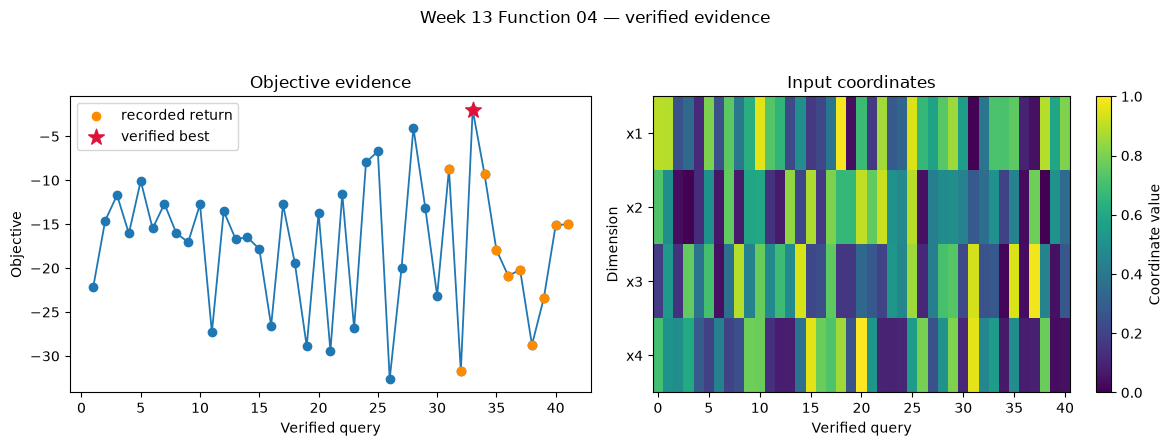

In [2]:
observations,summary,figure=analyse()
summary


<a id="descriptive-eda"></a>
## 6. Descriptive EDA

Inspect a bounded observation preview, full per-variable summary statistics, and the persisted function summary.

In [3]:
display(observations.head(10))
display(observations.describe().T)
display(pd.DataFrame([summary]))

,query,evidence,x1,x2,x3,x4,objective
0,1,starter,0.896981,0.725628,0.175404,0.701694,-22.108288
1,2,starter,0.889356,0.499588,0.539269,0.508783,-14.601397
2,3,starter,0.250946,0.033693,0.145380,0.494932,-11.699932
3,4,starter,0.346962,0.006250,0.760564,0.613024,-16.053765
4,5,starter,0.124871,0.129770,0.384400,0.287076,-10.069633
5,6,starter,0.801303,0.500231,0.706645,0.195103,-15.487083
6,7,starter,0.247708,0.060445,0.042186,0.441324,-12.681685
7,8,starter,0.746702,0.757092,0.369353,0.206566,-16.026400
8,9,starter,0.400665,0.072574,0.886768,0.243842,-17.049235
9,10,starter,0.626071,0.586751,0.438806,0.778858,-12.741766


,count,mean,std,min,25%,50%,75%,max
query,41.0,21.000000,11.979149,1.000000,11.000000,21.000000,31.000000,41.000000
x1,41.0,0.532988,0.298124,0.006280,0.250946,0.587928,0.753422,0.985622
x2,41.0,0.444355,0.291138,0.002958,0.166086,0.482103,0.666933,0.919592
x3,41.0,0.448666,0.292584,0.014095,0.217240,0.425826,0.709366,0.979511
x4,41.0,0.436220,0.305602,0.032616,0.111111,0.461856,0.723827,0.999483
objective,41.0,-17.321791,7.513169,-32.625660,-22.108288,-16.053765,-12.741766,-1.981075


,week,function,dimensions,starter_observations,recorded_pairs,total_verified_observations,best_query,best_input,best_output,latest_verified_query,latest_verified_input,latest_verified_output,latest_improves_previous_best,minimum_output,mean_output,standard_deviation,evidence_gap,interpretation,archive_integrity
0,13,4,4,30,11,41,33,"[0.394519, 0.361122, 0.256803, 0.461856]",-1.981075,41,"[0.80766, 0.348421, 0.277162, 0.044827]",-14.992666,False,-32.62566,-17.321791,7.420979,No verified Week 12 or Week 13 return is prese...,Within-function descriptive evidence; no causa...,Original repository Week 11 arrays remain quar...


<a id="visual-eda"></a>
## 7. Visual EDA

Display the function-level diagnostic figure generated from verified observations.

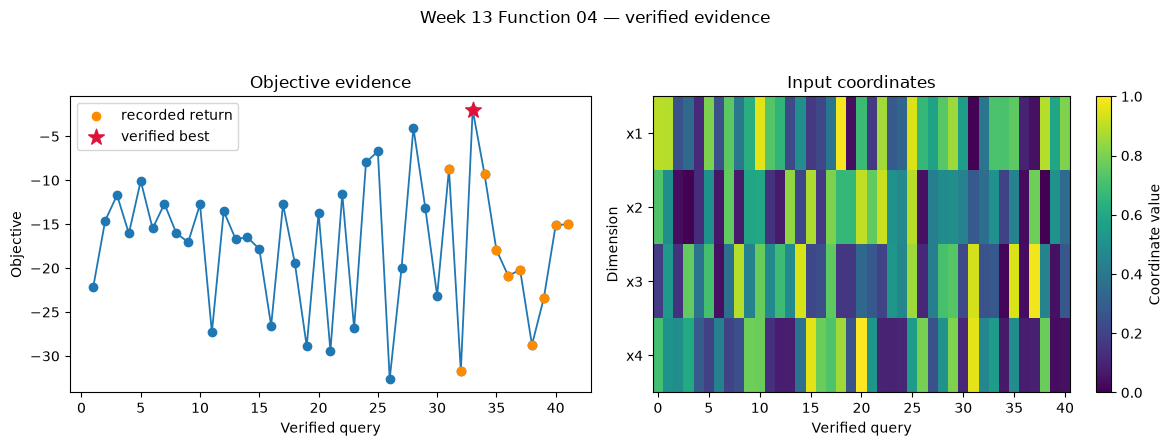

In [4]:
display(figure)

<a id="gp-model-configuration"></a>
## 8. GP model configuration

Load the canonical Week 13 GP-UCB row and expose the fitted kernel, candidate count, kappa, seed, and evidence count.

In [5]:
proposal_ledger = pd.read_csv(repo_root / 'Results' / 'week_13_gp_ucb_proposals.csv')
proposal = proposal_ledger.loc[proposal_ledger['function'].eq(4)].iloc[0]
display(proposal[['observation_count', 'kernel', 'candidate_count', 'kappa', 'random_seed']].to_frame('value'))

,value
observation_count,41
kernel,"4.38**2 * Matern(length_scale=[1.96, 1.9, 2, 2..."
candidate_count,20000
kappa,0.1
random_seed,4204


<a id="gp-ucb-values"></a>
## 9. GP-UCB values

Report the exact portal-formatted query, predicted mean, predictive uncertainty, and acquisition value.

In [6]:
display(proposal[['submission_query', 'predicted_mean', 'predictive_std', 'ucb_score', 'duplicate_at_6dp', 'status']].to_frame('value'))

,value
submission_query,0.370439-0.382408-0.425132-0.390887
predicted_mean,-1.352566
predictive_std,0.544867
ucb_score,-1.298079
duplicate_at_6dp,False
status,validated_proposal_only_week_12_and_13_returns...


<a id="reproducibility-checks"></a>
## 10. Reproducibility checks

Confirm data integrity and consistency between the focused notebook and the canonical proposal ledger.

In [7]:
assert observations.shape[0]==summary['total_verified_observations']
assert observations.filter(regex=r'^x').to_numpy().min()>=0
assert observations.filter(regex=r'^x').to_numpy().max()<=1
assert observations['objective'].notna().all()
print('All Week 13 Function 04 checks passed.')
assert summary['function'] == 4
assert int(proposal['observation_count']) == observations.shape[0]
assert not bool(proposal['duplicate_at_6dp'])
assert float(proposal['kappa']) == 0.1
print('All Week 13 Function 04 workflow checks passed.')

All Week 13 Function 04 checks passed.
All Week 13 Function 04 workflow checks passed.


<a id="conclusions-next-steps"></a>
## 11. Conclusions and next steps

Summarise the evidence-backed result without promoting a proposal to an observed return.

In [8]:
display(Markdown(f"**Verified observations:** {int(summary['total_verified_observations'])}  \n"f"**Best verified output:** {float(summary['best_output']):.8g}  \n"f"**Week 13 GP-UCB query:** `{proposal['submission_query']}`  \n"f"**UCB score:** {float(proposal['ucb_score']):.8g}  \n""Next step: append this point only after an authoritative returned output is available."))

**Verified observations:** 41  
**Best verified output:** -1.981075  
**Week 13 GP-UCB query:** `0.370439-0.382408-0.425132-0.390887`  
**UCB score:** -1.2980792  
Next step: append this point only after an authoritative returned output is available.